<a href="https://colab.research.google.com/github/ADITTYA-crate/UTS-CITRA-DIGITAL-/blob/main/UTS_CITRA_DIGITAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

JAWABAN 1

Saving IMG_20260426_125910.jpg to IMG_20260426_125910.jpg


/tmp/ipykernel_2372/3814702947.py:35: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img.ravel(), 256, [0,256])
/tmp/ipykernel_2372/3814702947.py:39: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(negative.ravel(), 256, [0,256])
/tmp/ipykernel_2372/3814702947.py:43: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(log_transform.ravel(), 256, [0,256])


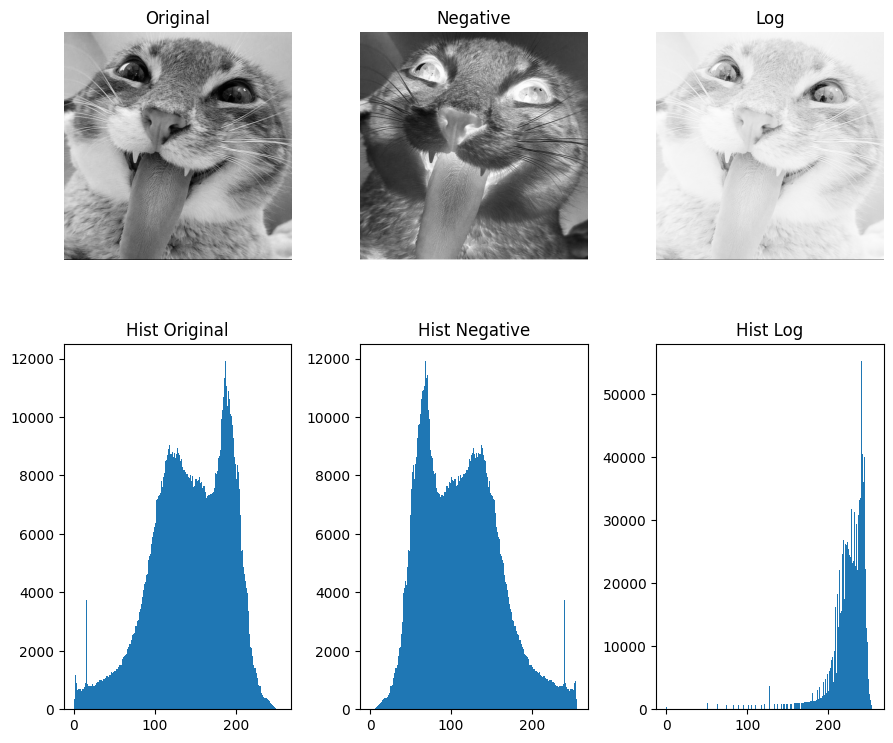

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()

img = cv2.imread(list(uploaded.keys())[0], 0)

negative = 255 - img

c = 255 / np.log(1 + np.max(img))
log_transform = c * np.log(1 + img)
log_transform = np.array(log_transform, dtype=np.uint8)

plt.figure(figsize=(12,8))

plt.subplot(2,4,1)
plt.title("Original")
plt.imshow(img, cmap='gray')
plt.axis("off")

plt.subplot(2,4,2)
plt.title("Negative")
plt.imshow(negative, cmap='gray')
plt.axis("off")

plt.subplot(2,4,3)
plt.title("Log")
plt.imshow(log_transform, cmap='gray')
plt.axis("off")

plt.subplot(2,4,5)
plt.title("Hist Original")
plt.hist(img.ravel(), 256, [0,256])

plt.subplot(2,4,6)
plt.title("Hist Negative")
plt.hist(negative.ravel(), 256, [0,256])

plt.subplot(2,4,7)
plt.title("Hist Log")
plt.hist(log_transform.ravel(), 256, [0,256])

plt.tight_layout()
plt.show()

JAWABAN 2

Saving IMG_20260426_125922.jpg to IMG_20260426_125922.jpg


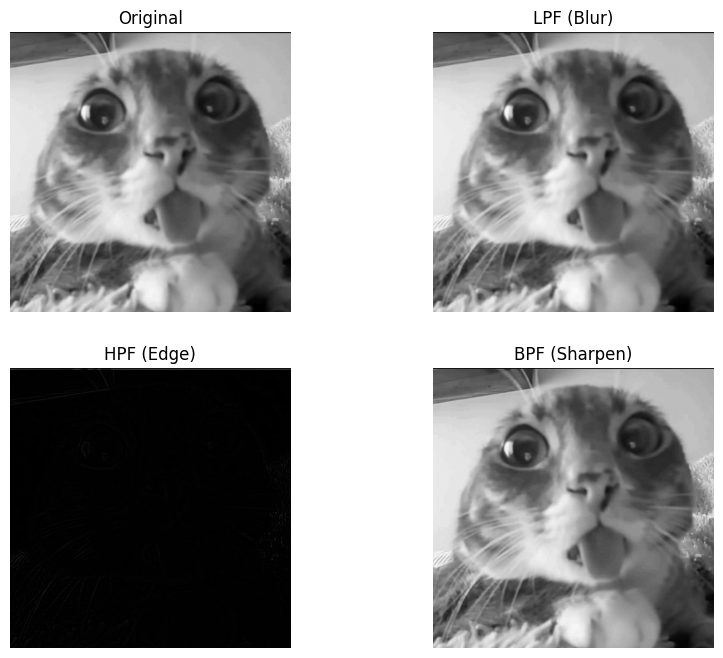

Mean Pixel:
Original: 135.68060623239194
LPF: 135.68131313131312
HPF: 2.179285198928056
BPF: 135.7337765409194


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()

img = cv2.imread(list(uploaded.keys())[0], 0)

kernel_lpf = (1/9) * np.array([[1,1,1],[1,1,1],[1,1,1]])
kernel_hpf = np.array([[-1,-1,-1],[-1,8,-1],[-1,-1,-1]])
kernel_bpf = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])

lpf = cv2.filter2D(img, -1, kernel_lpf)
hpf = cv2.filter2D(img, -1, kernel_hpf)
bpf = cv2.filter2D(img, -1, kernel_bpf)

mean_original = np.mean(img)
mean_lpf = np.mean(lpf)
mean_hpf = np.mean(hpf)
mean_bpf = np.mean(bpf)

plt.figure(figsize=(10,8))

plt.subplot(2,2,1)
plt.title("Original")
plt.imshow(img, cmap='gray')
plt.axis("off")

plt.subplot(2,2,2)
plt.title("LPF (Blur)")
plt.imshow(lpf, cmap='gray')
plt.axis("off")

plt.subplot(2,2,3)
plt.title("HPF (Edge)")
plt.imshow(hpf, cmap='gray')
plt.axis("off")

plt.subplot(2,2,4)
plt.title("BPF (Sharpen)")
plt.imshow(bpf, cmap='gray')
plt.axis("off")

plt.show()

print("Mean Pixel:")
print("Original:", mean_original)
print("LPF:", mean_lpf)
print("HPF:", mean_hpf)
print("BPF:", mean_bpf)